<a href="https://colab.research.google.com/github/harshitt018/Advance-Data-Science/blob/main/Loan_Approval_Prediction_using_XGBoost.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **1. Import Required Libraries**

In this cell, all the required libraries for data processing, visualization, machine learning, and XGBoost model building are imported.

These libraries help in:
- Handling the dataset
- Creating graphs and visualizations
- Preprocessing the data
- Training the machine learning model
- Evaluating model performance

Finally, warnings are ignored to keep the output clean and readable.

In [25]:
# IMPORT REQUIRED LIBRARIES

import pandas as pd
import numpy as np

# Visualization Libraries
import matplotlib.pyplot as plt
import seaborn as sns

# Preprocessing Libraries
from sklearn.preprocessing import LabelEncoder
from sklearn.impute import SimpleImputer

# Machine Learning Libraries
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    classification_report
)

# XGBoost
from xgboost import XGBClassifier
import xgboost as xgb

# Ignore warnings
import warnings
warnings.filterwarnings('ignore')

print("All Libraries Imported Successfully!")

All Libraries Imported Successfully!


# **2. Load Dataset & Display Basic Information**

In this cell, the training and testing datasets are loaded using the `read_csv()` function.

- The **training dataset** is used to train the XGBoost machine learning model.
- The **testing dataset** is used for final prediction and testing.

The first 5 rows of both datasets are displayed to understand the data structure and values.

The shape of the datasets is also displayed to check the number of rows and columns present.

Finally, `info()` is used to view:
- Column names
- Data types
- Non-null values
- Overall dataset information

In [26]:
# Load Training Dataset
train_data = pd.read_csv('/content/train_u6lujuX_CVtuZ9i.csv')

# Load Testing Dataset
test_data = pd.read_csv('/content/test_Y3wMUE5_7gLdaTN.csv')

# Display First 5 Rows of Training Data
print("Training Dataset:")
display(train_data.head())

# Display First 5 Rows of Testing Data
print("Testing Dataset:")
display(test_data.head())

# Shape of Datasets
print("Training Dataset Shape:", train_data.shape)
print("Testing Dataset Shape:", test_data.shape)

# Training Dataset Info
print("\nTraining Dataset Information:\n")
train_data.info()

Training Dataset:


,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,LP001002,Male,No,0,Graduate,No,5849,0.0,NaN,360.0,1.0,Urban,Y
1,LP001003,Male,Yes,1,Graduate,No,4583,1508.0,128.0,360.0,1.0,Rural,N
2,LP001005,Male,Yes,0,Graduate,Yes,3000,0.0,66.0,360.0,1.0,Urban,Y
3,LP001006,Male,Yes,0,Not Graduate,No,2583,2358.0,120.0,360.0,1.0,Urban,Y
4,LP001008,Male,No,0,Graduate,No,6000,0.0,141.0,360.0,1.0,Urban,Y


Testing Dataset:


,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area
0,LP001015,Male,Yes,0,Graduate,No,5720,0,110.0,360.0,1.0,Urban
1,LP001022,Male,Yes,1,Graduate,No,3076,1500,126.0,360.0,1.0,Urban
2,LP001031,Male,Yes,2,Graduate,No,5000,1800,208.0,360.0,1.0,Urban
3,LP001035,Male,Yes,2,Graduate,No,2340,2546,100.0,360.0,NaN,Urban
4,LP001051,Male,No,0,Not Graduate,No,3276,0,78.0,360.0,1.0,Urban


Training Dataset Shape: (614, 13)
Testing Dataset Shape: (367, 12)

Training Dataset Information:

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 614 entries, 0 to 613
Data columns (total 13 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Loan_ID            614 non-null    object 
 1   Gender             601 non-null    object 
 2   Married            611 non-null    object 
 3   Dependents         599 non-null    object 
 4   Education          614 non-null    object 
 5   Self_Employed      582 non-null    object 
 6   ApplicantIncome    614 non-null    int64  
 7   CoapplicantIncome  614 non-null    float64
 8   LoanAmount         592 non-null    float64
 9   Loan_Amount_Term   600 non-null    float64
 10  Credit_History     564 non-null    float64
 11  Property_Area      614 non-null    object 
 12  Loan_Status        614 non-null    object 
dtypes: float64(4), int64(1), object(8)
memory usage: 62.5+ KB


# **3. Check Missing Values**
In this cell, missing values present in both the training and testing datasets are identified using `isnull().sum()`.

The output shows that some columns contain missing data, such as:
- **Gender**
- **Dependents**
- **Self_Employed**
- **LoanAmount**
- **Credit_History**

Among all columns, **Credit_History** contains the highest number of missing values.

Checking missing values is an important preprocessing step because machine learning models cannot work properly with incomplete data.

In [27]:
# Missing values in training dataset
print("Missing Values in Training Dataset:\n")
print(train_data.isnull().sum())

# Missing values in testing dataset
print("\nMissing Values in Testing Dataset:\n")
print(test_data.isnull().sum())

Missing Values in Training Dataset:

Loan_ID               0
Gender               13
Married               3
Dependents           15
Education             0
Self_Employed        32
ApplicantIncome       0
CoapplicantIncome     0
LoanAmount           22
Loan_Amount_Term     14
Credit_History       50
Property_Area         0
Loan_Status           0
dtype: int64

Missing Values in Testing Dataset:

Loan_ID               0
Gender               11
Married               0
Dependents           10
Education             0
Self_Employed        23
ApplicantIncome       0
CoapplicantIncome     0
LoanAmount            5
Loan_Amount_Term      6
Credit_History       29
Property_Area         0
dtype: int64


# **4. Handle Missing Values**
In this cell, missing values in the dataset are cleaned and replaced.

- Missing values in categorical columns such as **Gender**, **Married**, and **Credit_History** are filled using the **mode** (most frequent value).
- Missing values in numerical columns such as **LoanAmount** are filled using the **median** value.

After preprocessing, the output shows that all missing values have been successfully removed from both the training and testing datasets.

This step is important because machine learning models require clean and complete data for better prediction accuracy.

In [28]:
# Categorical Columns
categorical_columns = [
    'Gender',
    'Married',
    'Dependents',
    'Self_Employed',
    'Loan_Amount_Term',
    'Credit_History'
]

# Fill categorical missing values with mode
for col in categorical_columns:
    train_data[col].fillna(train_data[col].mode()[0], inplace=True)
    test_data[col].fillna(test_data[col].mode()[0], inplace=True)

# Numerical Columns
numerical_columns = ['LoanAmount']

# Fill numerical missing values with median
for col in numerical_columns:
    train_data[col].fillna(train_data[col].median(), inplace=True)
    test_data[col].fillna(test_data[col].median(), inplace=True)

# Check if missing values are removed
print("Missing Values in Training Dataset After Cleaning:\n")
print(train_data.isnull().sum())

print("\nMissing Values in Testing Dataset After Cleaning:\n")
print(test_data.isnull().sum())

Missing Values in Training Dataset After Cleaning:

Loan_ID              0
Gender               0
Married              0
Dependents           0
Education            0
Self_Employed        0
ApplicantIncome      0
CoapplicantIncome    0
LoanAmount           0
Loan_Amount_Term     0
Credit_History       0
Property_Area        0
Loan_Status          0
dtype: int64

Missing Values in Testing Dataset After Cleaning:

Loan_ID              0
Gender               0
Married              0
Dependents           0
Education            0
Self_Employed        0
ApplicantIncome      0
CoapplicantIncome    0
LoanAmount           0
Loan_Amount_Term     0
Credit_History       0
Property_Area        0
dtype: int64


# **5. Label Encoding**
In this cell, categorical text data is converted into numerical form using **Label Encoding**.

Machine learning models cannot understand text values such as:
- Male / Female
- Yes / No
- Urban / Rural

Therefore, these values are converted into numbers for better model training and prediction.

The output shows the encoded training and testing datasets after conversion.

## Encoding Conversion Table

| Original Value | Encoded Value |
|---|---|
| Male | 1 |
| Female | 0 |
| Yes | 1 |
| No | 0 |
| Graduate | 0 |
| Not Graduate | 1 |
| Urban | 2 |
| Semiurban | 1 |
| Rural | 0 |
| Loan Approved (Y) | 1 |
| Loan Rejected (N) | 0 |

In [29]:
# Create LabelEncoder object
label_encoder = LabelEncoder()

# Categorical Columns to Encode
categorical_cols = [
    'Gender',
    'Married',
    'Dependents',
    'Education',
    'Self_Employed',
    'Property_Area',
    'Loan_Status'
]

# Apply Label Encoding on Training Data
for col in categorical_cols:
    train_data[col] = label_encoder.fit_transform(train_data[col])

# Apply Label Encoding on Testing Data
test_cols = [
    'Gender',
    'Married',
    'Dependents',
    'Education',
    'Self_Employed',
    'Property_Area'
]

for col in test_cols:
    test_data[col] = label_encoder.fit_transform(test_data[col])

# Display Encoded Training Data
print("Encoded Training Dataset:\n")
display(train_data.head())

# Display Encoded Testing Data
print("\nEncoded Testing Dataset:\n")
display(test_data.head())

Encoded Training Dataset:



,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,LP001002,1,0,0,0,0,5849,0.0,128.0,360.0,1.0,2,1
1,LP001003,1,1,1,0,0,4583,1508.0,128.0,360.0,1.0,0,0
2,LP001005,1,1,0,0,1,3000,0.0,66.0,360.0,1.0,2,1
3,LP001006,1,1,0,1,0,2583,2358.0,120.0,360.0,1.0,2,1
4,LP001008,1,0,0,0,0,6000,0.0,141.0,360.0,1.0,2,1



Encoded Testing Dataset:



,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area
0,LP001015,1,1,0,0,0,5720,0,110.0,360.0,1.0,2
1,LP001022,1,1,1,0,0,3076,1500,126.0,360.0,1.0,2
2,LP001031,1,1,2,0,0,5000,1800,208.0,360.0,1.0,2
3,LP001035,1,1,2,0,0,2340,2546,100.0,360.0,1.0,2
4,LP001051,1,0,0,1,0,3276,0,78.0,360.0,1.0,2


# **6. Data Visualization**
In this cell, different graphs are created to analyze and understand the dataset visually.

The visualizations help identify important patterns and relationships between features affecting loan approval.

### Graph Analysis:
- **Loan Approval Status:** Shows that most loan applications were approved.
- **Credit History vs Loan Status:** Applicants with good credit history have a higher chance of loan approval.
- **Property Area Distribution:** Most applicants belong to semiurban areas.
- **Loan Amount Distribution:** Most loan amounts are concentrated between lower and medium ranges.

Data visualization helps in better understanding of the dataset before training the machine learning model.

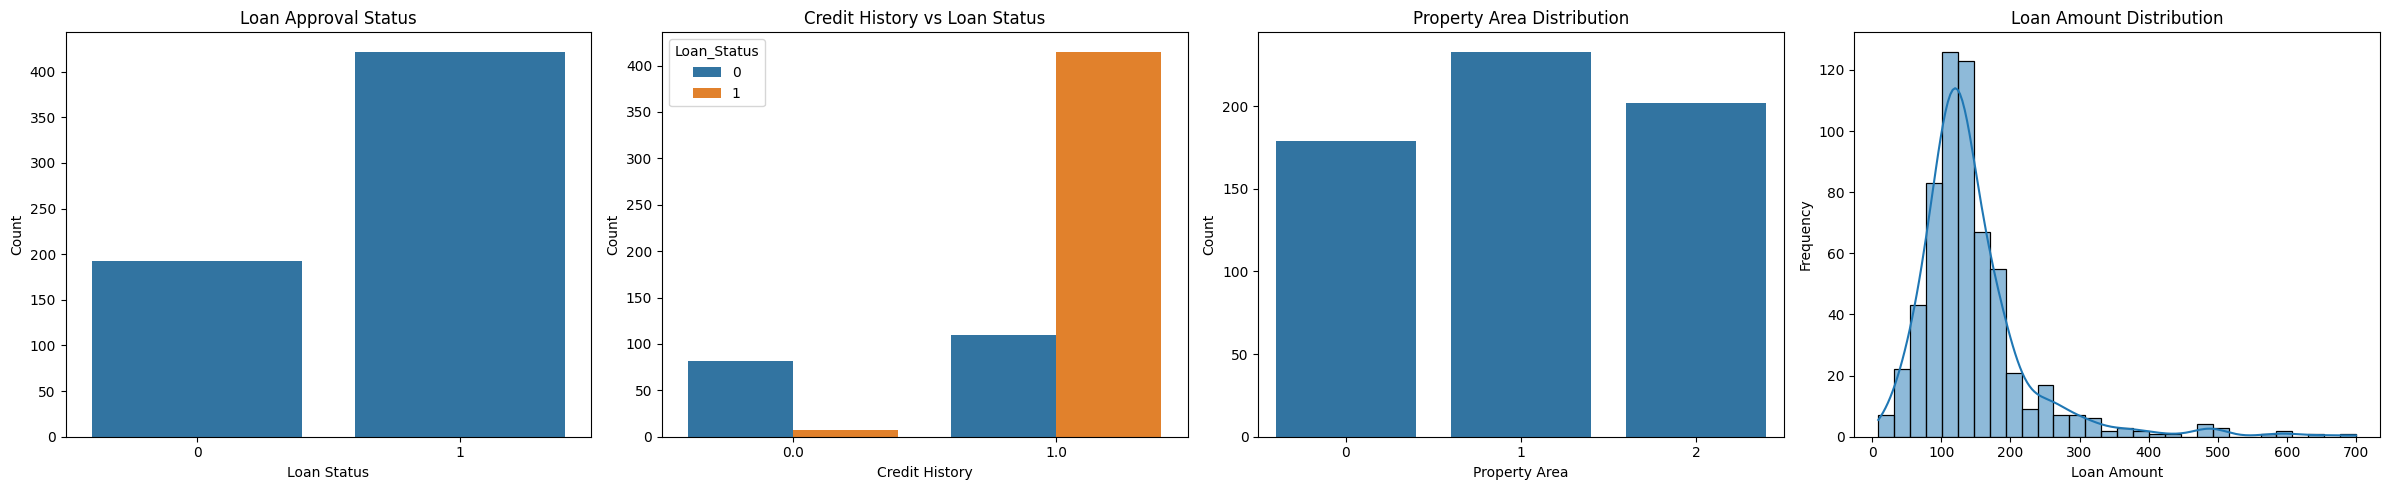

In [30]:
# Create Figure
fig, axes = plt.subplots(1, 4, figsize=(24,5))

# 1. Loan Approval Status
sns.countplot(
    x='Loan_Status',
    data=train_data,
    ax=axes[0]
)

axes[0].set_title("Loan Approval Status")
axes[0].set_xlabel("Loan Status")
axes[0].set_ylabel("Count")


# 2. Credit History vs Loan Status
sns.countplot(
    x='Credit_History',
    hue='Loan_Status',
    data=train_data,
    ax=axes[1]
)

axes[1].set_title("Credit History vs Loan Status")
axes[1].set_xlabel("Credit History")
axes[1].set_ylabel("Count")


# 3. Property Area Distribution
sns.countplot(
    x='Property_Area',
    data=train_data,
    ax=axes[2]
)

axes[2].set_title("Property Area Distribution")
axes[2].set_xlabel("Property Area")
axes[2].set_ylabel("Count")


# 4. Loan Amount Distribution
sns.histplot(
    train_data['LoanAmount'],
    bins=30,
    kde=True,
    ax=axes[3]
)

axes[3].set_title("Loan Amount Distribution")
axes[3].set_xlabel("Loan Amount")
axes[3].set_ylabel("Frequency")


plt.tight_layout()
plt.show()

# **7. Prepare Features & Target Variable**
In this cell, the dataset is divided into:
- **Features (X)** → Input data used for prediction
- **Target Variable (y)** → Output data to be predicted

### Important Steps:
- The `Loan_ID` column is removed because it does not affect loan prediction.
- `Loan_Status` is separated as the target variable since it contains the final approval result.

### Output Analysis:
- `X.shape = (614, 11)` shows that the dataset contains **614 rows** and **11 input features**.
- `y.shape = (614,)` shows that there are **614 target values** for prediction.

The output also displays:
- The first 5 rows of the feature dataset
- The first 5 values of the target variable

This step is important because machine learning models require separate input and output data for training.

In [31]:
# Drop Loan_ID column
train_data = train_data.drop('Loan_ID', axis=1)
test_data = test_data.drop('Loan_ID', axis=1)

# Features (Input Data)
X = train_data.drop('Loan_Status', axis=1)

# Target Variable (Output Data)
y = train_data['Loan_Status']

# Display Shapes
print("Shape of X (Features):", X.shape)
print("Shape of y (Target):", y.shape)

# Display First 5 Rows of Features
print("\nFeatures Dataset:")
display(X.head())

# Display First 5 Target Values
print("\nTarget Variable:")
display(y.head())

Shape of X (Features): (614, 11)
Shape of y (Target): (614,)

Features Dataset:


,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area
0,1,0,0,0,0,5849,0.0,128.0,360.0,1.0,2
1,1,1,1,0,0,4583,1508.0,128.0,360.0,1.0,0
2,1,1,0,0,1,3000,0.0,66.0,360.0,1.0,2
3,1,1,0,1,0,2583,2358.0,120.0,360.0,1.0,2
4,1,0,0,0,0,6000,0.0,141.0,360.0,1.0,2



Target Variable:


,Loan_Status
0,1
1,0
2,1
3,1
4,1


# **8. Train Test Split**

In this cell, the dataset is divided into training and testing sets using `train_test_split()`.

### Important Parameters:
- `test_size = 0.2`
  - 80% data is used for training
  - 20% data is used for testing

- `random_state = 42`
  - Ensures consistent and reproducible results every time the code runs.

### Output Analysis:
- `X_train Shape: (491, 11)`
  - 491 rows and 11 features are used for training the model.

- `X_test Shape: (123, 11)`
  - 123 rows and 11 features are used for testing the model.

- `y_train Shape: (491,)`
  - Contains training target values.

- `y_test Shape: (123,)`
  - Contains testing target values.

This step is important because the model learns from training data and is evaluated using unseen testing data.

In [32]:
# Split Dataset into Training and Testing Sets
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

# Display Shapes
print("X_train Shape:", X_train.shape)
print("X_test Shape:", X_test.shape)

print("\ny_train Shape:", y_train.shape)
print("y_test Shape:", y_test.shape)

X_train Shape: (491, 11)
X_test Shape: (123, 11)

y_train Shape: (491,)
y_test Shape: (123,)


# **9. Train XGBoost Model**
In this cell, the XGBoost classification model is created and trained using the training dataset.

### Important Parameters:
- `n_estimators = 100` → Creates 100 decision trees
- `max_depth = 4` → Sets the maximum depth of each tree
- `learning_rate = 0.01` → Controls the learning speed of the model
- `objective = 'binary:logistic'` → Used for binary classification (Approved / Rejected)

Finally, the model is trained using `model.fit()` and a success message is displayed after training is completed.

In [33]:
# Create XGBoost Classifier Model
model = XGBClassifier(
    n_estimators=100,
    max_depth=4,
    learning_rate=0.01,
    objective='binary:logistic',
    random_state=42
)

# Train the Model
model.fit(X_train, y_train)

print("XGBoost Model Trained Successfully!")

XGBoost Model Trained Successfully!


# **10. Accuracy Score**
In this cell, predictions are made using the testing dataset and the performance of the XGBoost model is evaluated.

### Important Steps:
- `model.predict()` is used to predict loan approval results.
- `accuracy_score()` calculates the overall prediction accuracy of the model.
- `classification_report()` displays detailed evaluation metrics such as precision, recall, and f1-score.

### Output Analysis:
- The model achieved an accuracy of **78.86%**.
- The classification report shows that the model performs well in predicting approved loans.

This step is important to measure how accurately the machine learning model performs on unseen data.

In [47]:
# Predict on Test Data
y_pred = model.predict(X_test)

# ACCURACY SCORE
accuracy = accuracy_score(y_test, y_pred)
print("Model Accuracy:", round(accuracy * 100, 2), "%")

# CLASSIFICATION REPORT
print("\nClassification Report:\n")
print(classification_report(y_test, y_pred))

Model Accuracy: 78.86 %

Classification Report:

              precision    recall  f1-score   support

           0       0.95      0.42      0.58        43
           1       0.76      0.99      0.86        80

    accuracy                           0.79       123
   macro avg       0.85      0.70      0.72       123
weighted avg       0.83      0.79      0.76       123



# **11. Confusion Matrix Visualization**
In this cell, a confusion matrix is created to evaluate the performance of the XGBoost model.

A heatmap is used to visually display:
- Correct predictions
- Incorrect predictions

### Output Analysis:
| Actual Value | Predicted Value | Meaning |
|---|---|---|
| 18 | Rejected Correctly | Model correctly predicted loan rejection |
| 79 | Approved Correctly | Model correctly predicted loan approval |
| 25 | Wrongly Approved | Actual loan was rejected, but model predicted approved |
| 1 | Wrongly Rejected | Actual loan was approved, but model predicted rejected |

The confusion matrix helps in understanding how well the model performs in classification tasks.

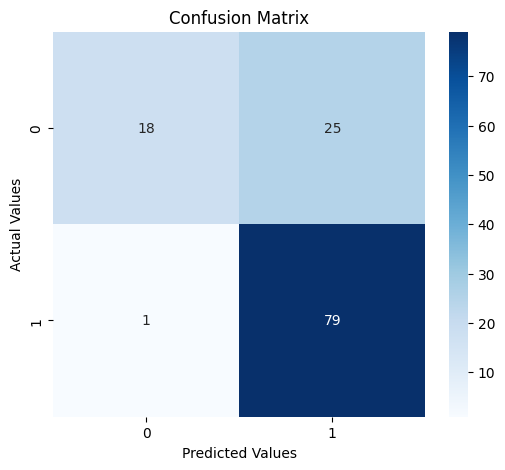

In [35]:
# Create Confusion Matrix
cm = confusion_matrix(y_test, y_pred)

# Plot Heatmap
plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues'
)

# Labels & Title
plt.xlabel("Predicted Values")
plt.ylabel("Actual Values")
plt.title("Confusion Matrix")

plt.show()

# **12. Feature Importance Graph**
In this cell, a **Feature Importance Graph** is created using XGBoost to identify which features have the greatest impact on loan approval prediction.

### Code Explanation:
- `plt.figure(figsize=(10,6))`
  - Creates a graph figure with custom width and height.

- `xgb.plot_importance(model)`
  - Plots the importance score of each feature used by the XGBoost model.

- `plt.title()`
  - Adds a title to the graph.

- `plt.show()`
  - Displays the final graph.

---

### Why it is Used:
This graph helps in understanding which features contribute the most to prediction and how the model makes decisions.

---

# How Does it Work?

XGBoost internally calculates how useful each feature is during decision tree creation.

Features that help the model make better predictions receive higher importance scores.

The graph ranks all features from most important to least important.

---

# Output Analysis

From the graph:
- **LoanAmount** has the highest importance score.
- **CoapplicantIncome** and **Credit_History** also strongly affect loan approval prediction.
- **Self_Employed** has the lowest importance score.

Higher bars indicate features that influence the prediction more strongly.

---

# Conclusion

The Feature Importance Graph helps in understanding which applicant details are most responsible for loan approval prediction in the XGBoost model.

<Figure size 1000x600 with 0 Axes>

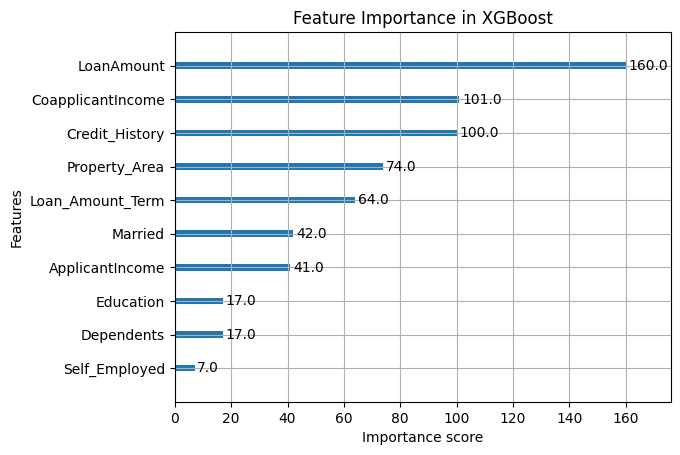

In [36]:
# Create Figure
plt.figure(figsize=(10,6))

# Plot Feature Importance
xgb.plot_importance(model)

# Title
plt.title("Feature Importance in XGBoost")

# Show Plot
plt.show()

# **13. XGBoost Tree Visualization**


The tree starts from the left side and moves toward the right side step-by-step.

Each node contains a condition based on a feature value.

### Flow of the Tree:
1. The model first checks a condition such as:
   - `Credit_History < 1`

2. If the condition is true:
   - The model follows one branch.

3. If the condition is false:
   - The model follows another branch.

4. The process continues with more conditions like:
   - `LoanAmount < 300`
   - `Property_Area < 1`

5. Finally, the model reaches a final node called a **Leaf Node**.

---

# What is a Leaf Node?

A leaf node is the final endpoint of the tree where the prediction result is generated.

It does not contain any more conditions or branches.

The value inside the leaf node represents the prediction score used by the model for loan approval or rejection.

### Simple Meaning:
- Start Node → Decision Checking
- Middle Nodes → More Conditions
- Leaf Node → Final Prediction Result

---

# Easy Understanding

The tree works like a flowchart:
- Check condition
- Move left or right
- Check another condition
- Reach final prediction

This is how XGBoost makes decisions internally for loan approval prediction.

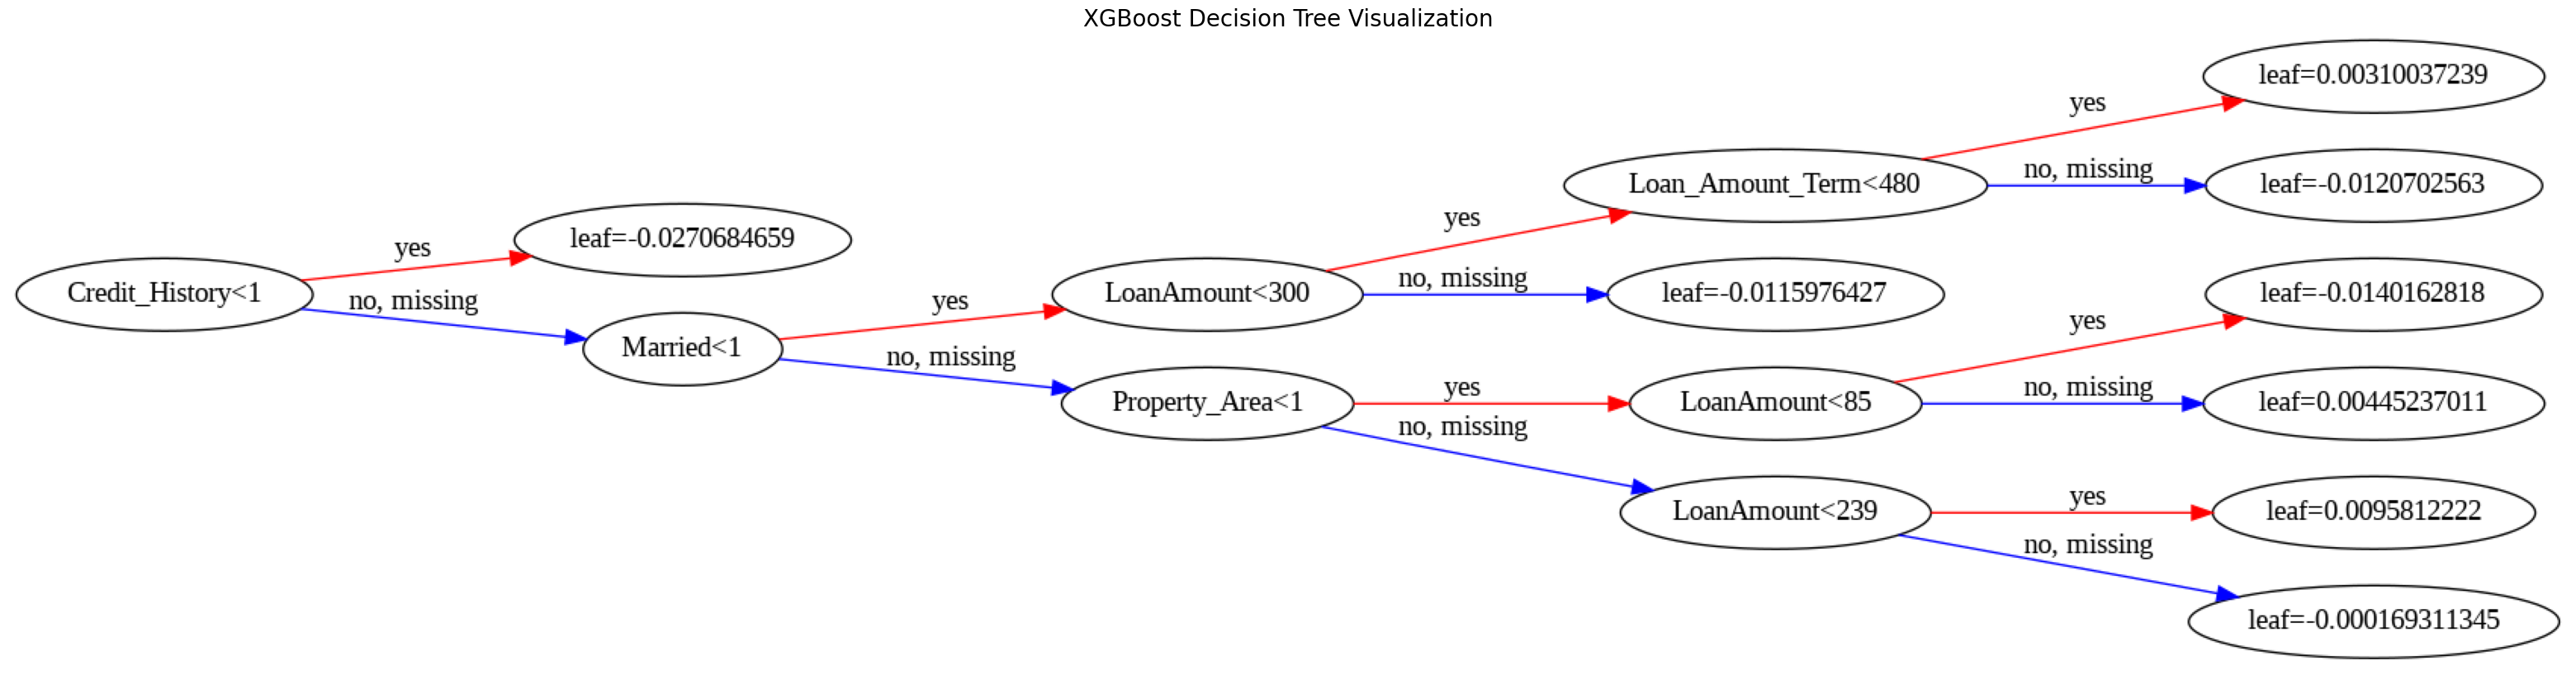

In [40]:
# Create Large Figure
fig, ax = plt.subplots(figsize=(40, 20))

# Plot Tree
xgb.plot_tree(
    model,
    num_trees=0,
    rankdir='LR',
    ax=ax
)

# Add Title
plt.title(
    "XGBoost Decision Tree Visualization",
    fontsize=20
)

# Show Plot
plt.show()

# **14. Predict Using Testing Dataset**
The model uses different input features to predict whether the loan should be approved or rejected.

Some features have a higher impact on prediction compared to others.

| Input Feature | Purpose | Importance Level |
|---|---|---|
| Credit_History | Checks previous loan repayment history | Very High |
| LoanAmount | Loan amount requested by applicant | High |
| CoapplicantIncome | Income of co-applicant | High |
| ApplicantIncome | Main applicant income | Medium |
| Property_Area | Applicant living area | Medium |
| Loan_Amount_Term | Loan repayment duration | Medium |
| Married | Marital status of applicant | Low |
| Education | Education qualification | Low |
| Dependents | Number of dependents | Low |
| Self_Employed | Employment type | Very Low |
| Gender | Gender of applicant | Very Low |

---

# Highest Weightage Feature

## Credit_History

`Credit_History` has the highest importance because it shows whether the applicant has previously repaid loans properly or not.

### Meaning:
- `1` → Good credit history → Higher chance of approval
- `0` → Bad credit history → Higher chance of rejection

The model strongly depends on this feature while making loan approval predictions.

In [46]:
print("===== LOAN APPROVAL PREDICTION SYSTEM =====")

# User Inputs
gender = int(input("Gender (Male=1, Female=0): "))
married = int(input("Married (Yes=1, No=0): "))
dependents = int(input("Dependents (0/1/2/3): "))
education = int(input("Education (Graduate=0, Not Graduate=1): "))
self_employed = int(input("Self Employed (No=0, Yes=1): "))

applicant_income = float(input("Applicant Income: "))
coapplicant_income = float(input("Coapplicant Income: "))
loan_amount = float(input("Loan Amount: "))
loan_amount_term = float(input("Loan Amount Term: "))

credit_history = int(input("Credit History (1=Good, 0=Bad): "))
property_area = int(input("Property Area (Rural=0, Semiurban=1, Urban=2): "))

# Create DataFrame
user_data = pd.DataFrame({
    'Gender': [gender],
    'Married': [married],
    'Dependents': [dependents],
    'Education': [education],
    'Self_Employed': [self_employed],
    'ApplicantIncome': [applicant_income],
    'CoapplicantIncome': [coapplicant_income],
    'LoanAmount': [loan_amount],
    'Loan_Amount_Term': [loan_amount_term],
    'Credit_History': [credit_history],
    'Property_Area': [property_area]
})

# Prediction
prediction = model.predict(user_data)

# Probability Prediction
probability = model.predict_proba(user_data)

# Approval & Rejection %
approved_percentage = probability[0][1] * 100
rejected_percentage = probability[0][0] * 100

# Final Result
if prediction[0] == 1:
    print("\n✅ Loan Approved")
else:
    print("\n❌ Loan Rejected")

# Display Percentages
print(f"\nApproval Probability: {approved_percentage:.2f}%")
print(f"Rejection Probability: {rejected_percentage:.2f}%")

===== LOAN APPROVAL PREDICTION SYSTEM =====
Gender (Male=1, Female=0): 1
Married (Yes=1, No=0): 1
Dependents (0/1/2/3): 1
Education (Graduate=0, Not Graduate=1): 0
Self Employed (No=0, Yes=1): 0
Applicant Income: 3500
Coapplicant Income: 1500
Loan Amount: 200
Loan Amount Term: 360
Credit History (1=Good, 0=Bad): 1
Property Area (Rural=0, Semiurban=1, Urban=2): 1

✅ Loan Approved

Approval Probability: 81.93%
Rejection Probability: 18.07%
